BAKERY SALES DATASET - INITIAL EXPLORATION

Dataset Shape: 1001 rows × 7 columns

Column Names: ['Date', 'City', 'Confectionary', 'Units Sold', 'Revenue(£)', 'Cost(£)', 'Profit(£)']

Data Types:
Date             datetime64[ns]
City                     object
Confectionary            object
Units Sold              float64
Revenue(£)              float64
Cost(£)                 float64
Profit(£)               float64
dtype: object

First 5 Rows:
        Date    City Confectionary  Units Sold  Revenue(£)  Cost(£)  Profit(£)
0 2002-11-11  London       Biscuit      1118.0      5590.0   2459.6     3130.4
1 2002-07-05  London       Biscuit       708.0      3540.0   1557.6     1982.4
2 2001-10-31  London       Biscuit      1269.0      6345.0   2791.8     3553.2
3 2004-09-13  London       Biscuit      1631.0      8155.0   3588.2     4566.8
4 2004-03-10  London       Biscuit      2240.0     11200.0   4928.0     6272.0

Missing Values:
Date             0
City             0
Confectionary    0
Unit

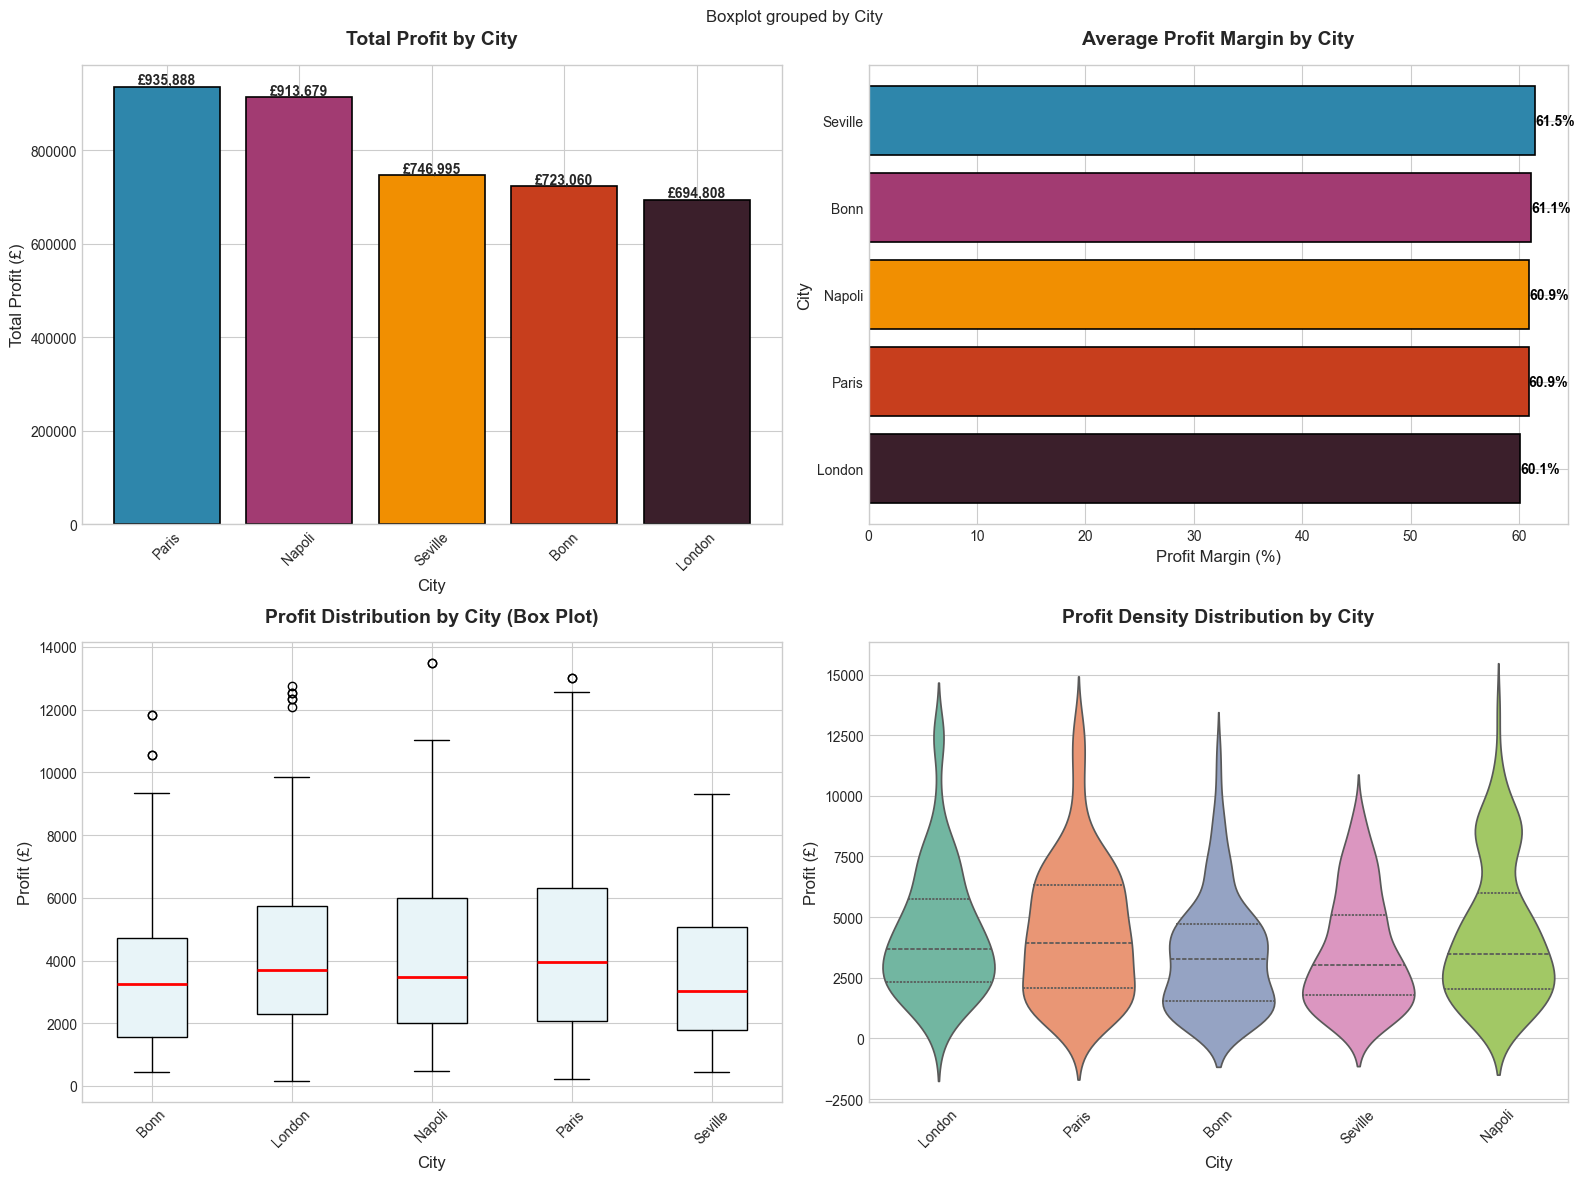

✓ Figure 1 saved: City-wise Profitability Analysis


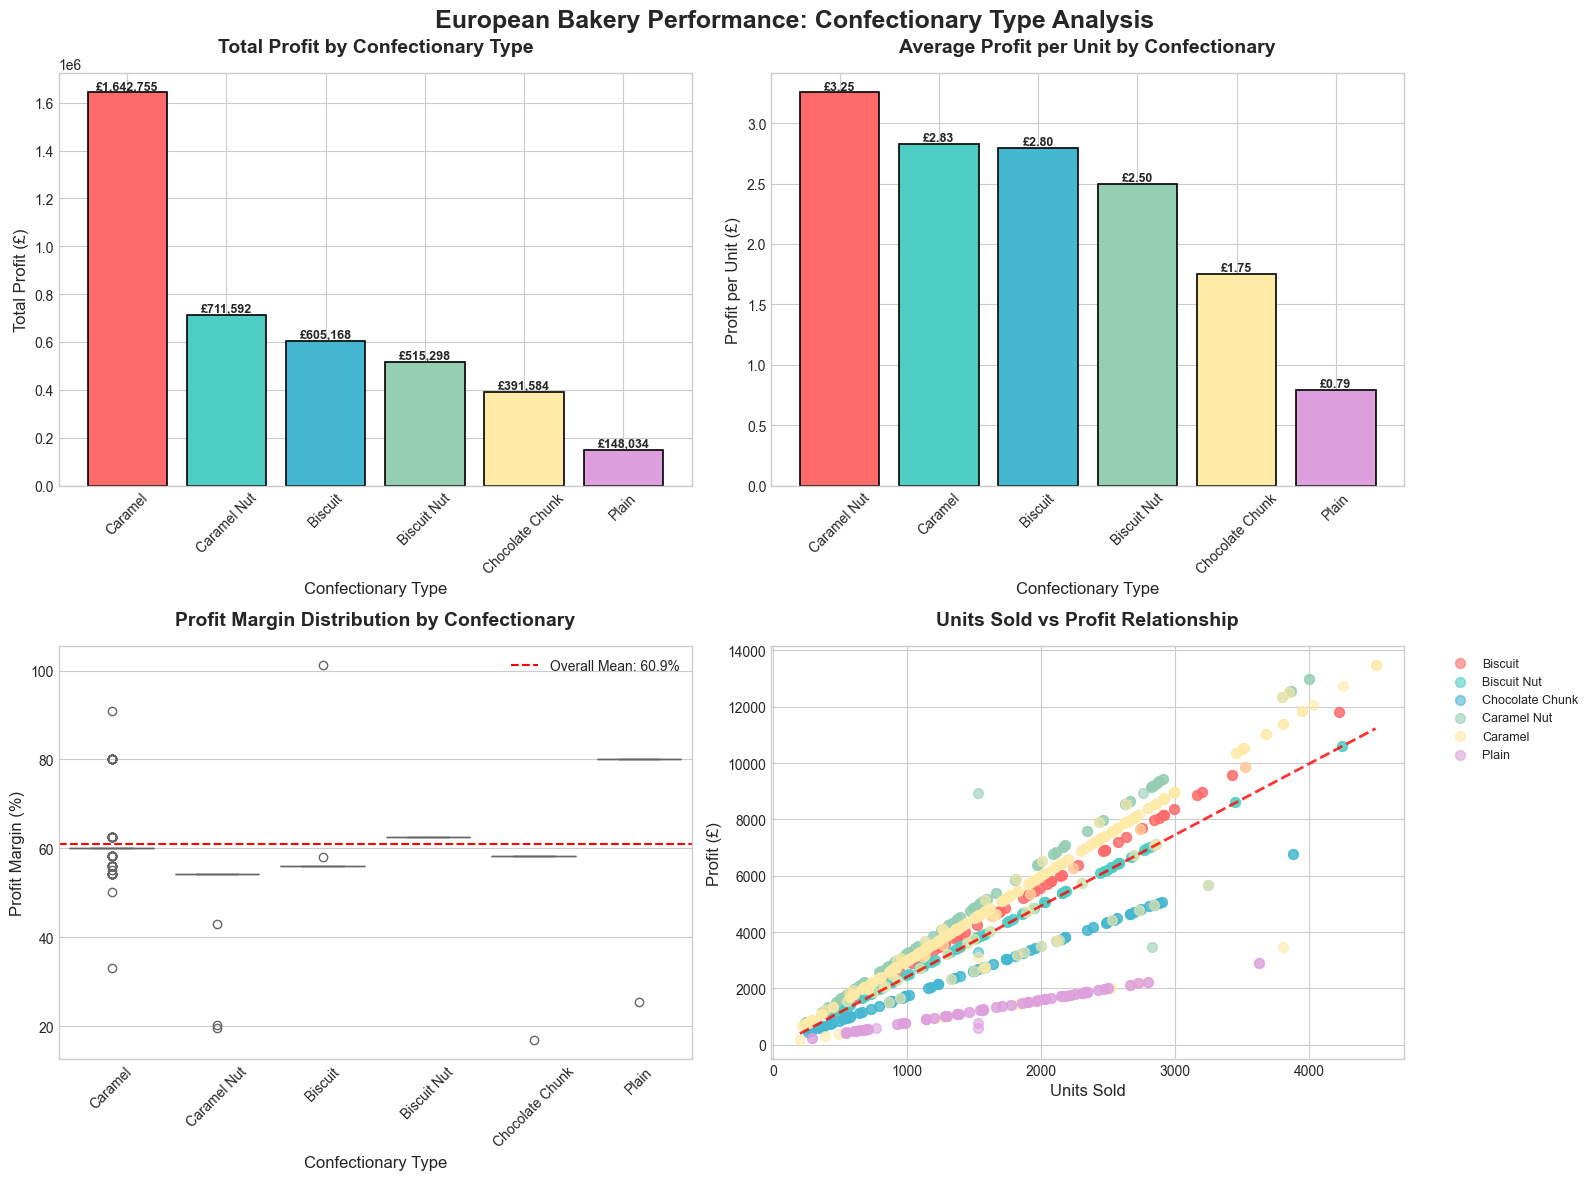

✓ Figure 2 saved: Confectionary Type Analysis

STATISTICAL HYPOTHESIS TESTING & PROBABILITY ANALYSIS

1. ONE-WAY ANOVA: Profit Differences Across Cities
------------------------------------------------------------
F-statistic: 7.0249
p-value: 0.000014
Significance Level (α): 0.05
✓ RESULT: Significant difference in mean profit across cities (Reject H₀)

2. INDEPENDENT T-TEST: Paris vs London Profit Comparison
------------------------------------------------------------
Paris Mean Profit: £4456.61 (±2810.39)
London Mean Profit: £4315.57 (±2642.09)
t-statistic: 0.4916
p-value: 0.623285
✗ RESULT: No significant difference between Paris and London profits

3. CHI-SQUARE TEST: City vs Confectionary Type Independence
------------------------------------------------------------
Chi-square statistic: 90.3785
p-value: 0.000000
Degrees of freedom: 20
✓ RESULT: City and Confectionary Type are dependent (Reject H₀)

4. PEARSON CORRELATION: Units Sold vs Profit
-------------------------------------

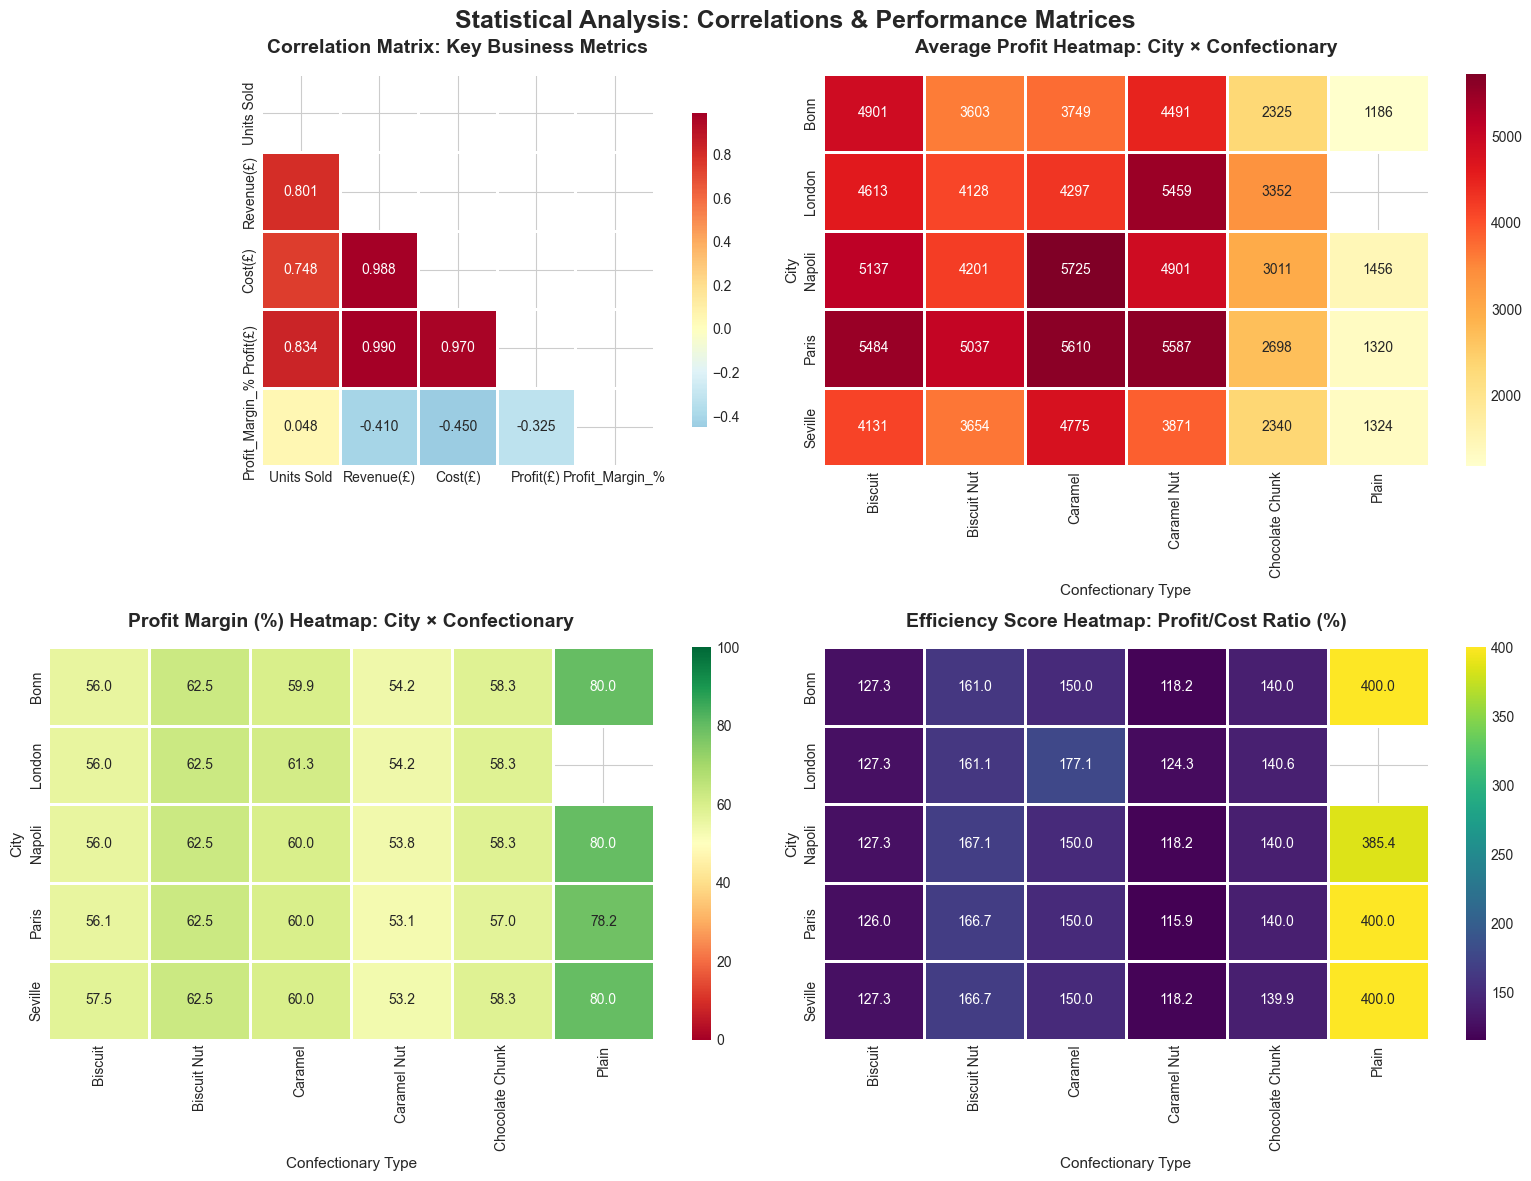

✓ Figure 3 saved: Correlation & Heatmap Analysis


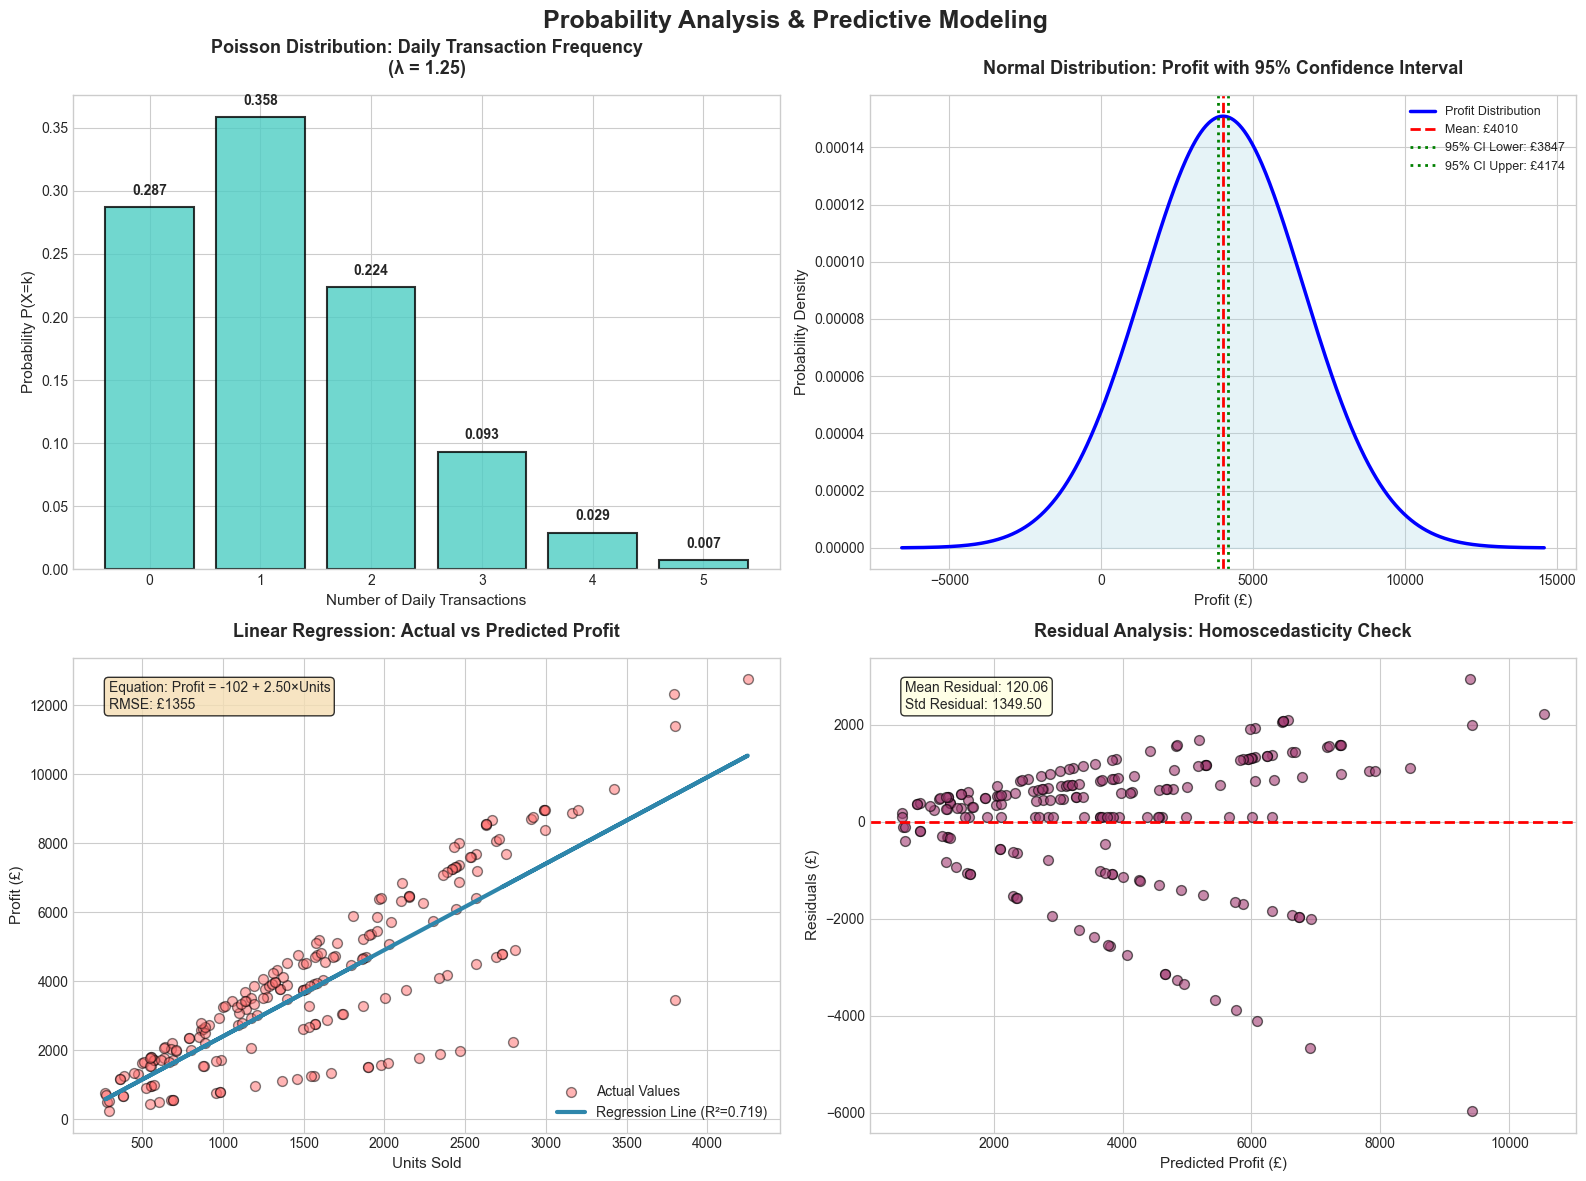

✓ Figure 4 saved: Probability Analysis & Predictive Modeling


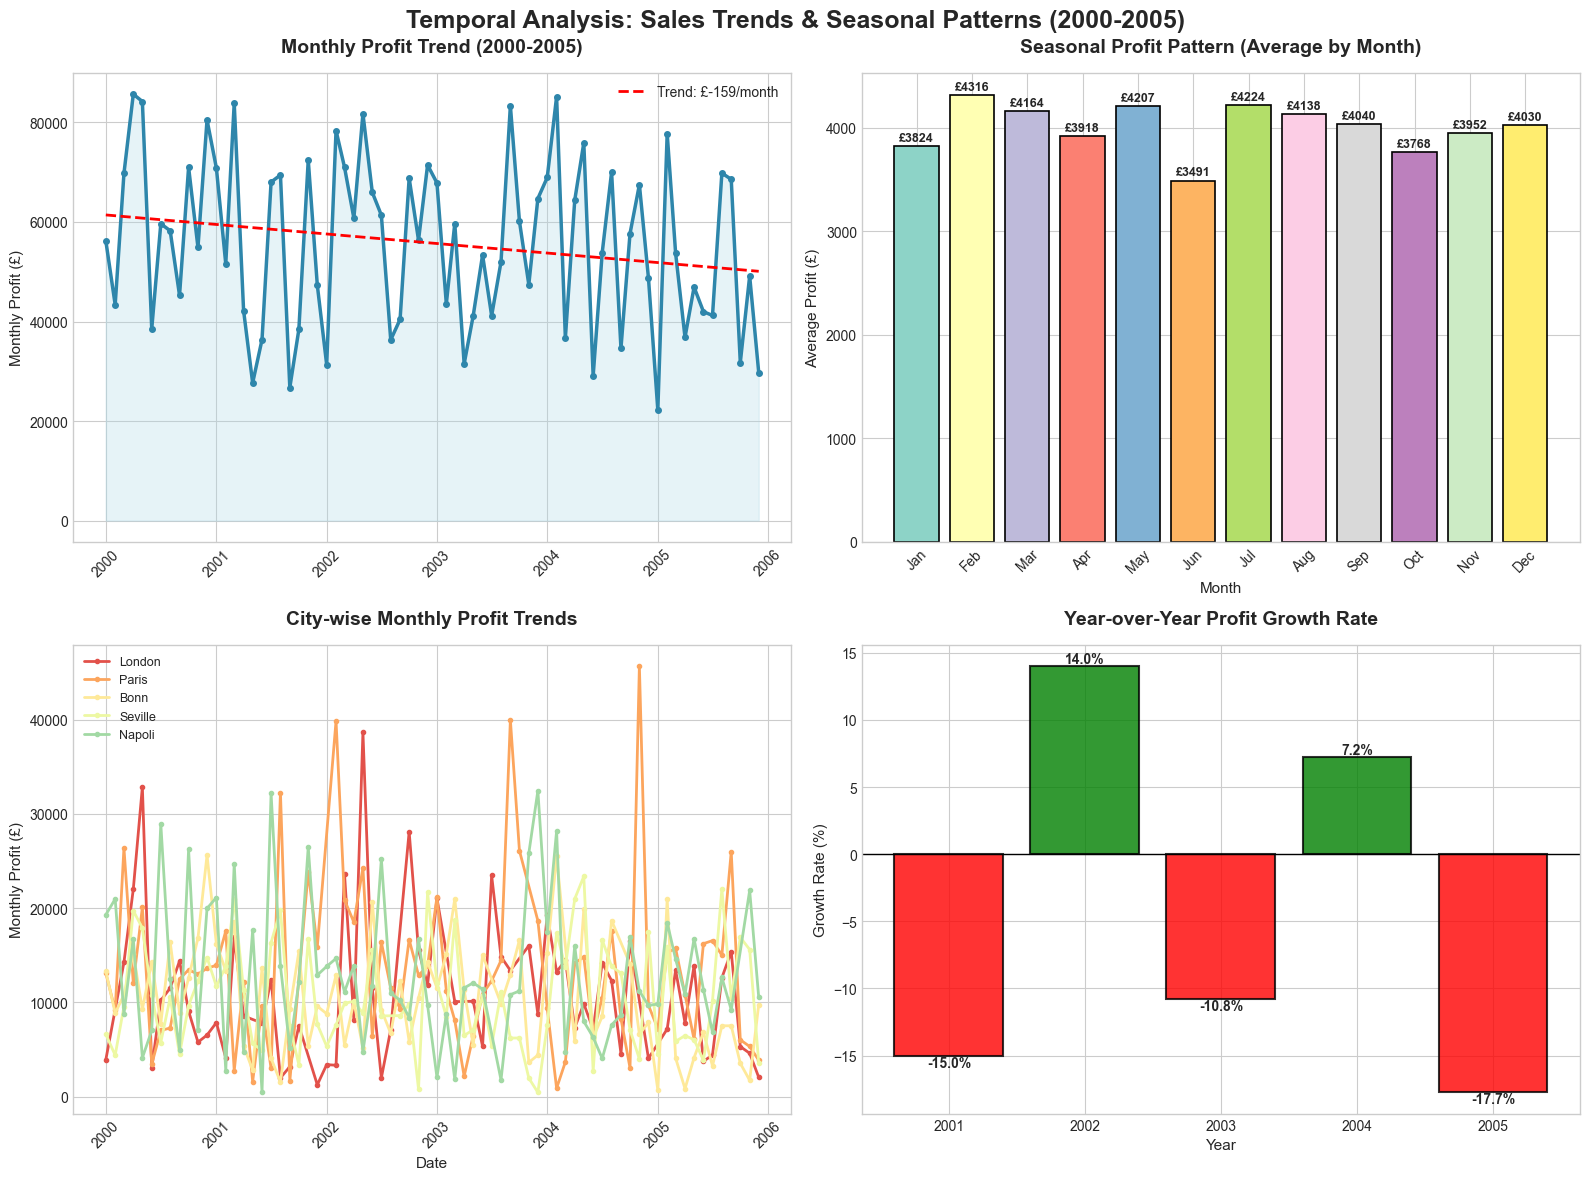

✓ Figure 5 saved: Temporal Analysis & Trend Forecasting

BUILDING INTERACTIVE EUROPEAN DASHBOARD
City Summary Statistics:
      City  Total_Profit  Avg_Profit  Std_Profit  Transactions  Total_Revenue  \
0     Bonn      723059.5     3443.14     2375.94           210      1231874.0   
1   London      694807.5     4315.57     2642.09           161      1190692.0   
2   Napoli      913678.7     4350.85     2892.26           210      1554105.0   
3    Paris      935888.2     4456.61     2810.39           210      1607054.0   
4  Seville      746995.0     3557.12     2299.38           210      1262799.0   

   Total_Cost  Total_Units  Avg_Margin  Profit_per_Unit  
0   510834.60     295210.5       61.10             2.45  
1   492595.25     281887.5       60.09             2.46  
2   641348.40     369627.0       60.95             2.47  
3   658073.50     379222.0       60.91             2.47  
4   516888.80     308532.5       61.46             2.42  

✓ Interactive Dashboard saved as 'interact

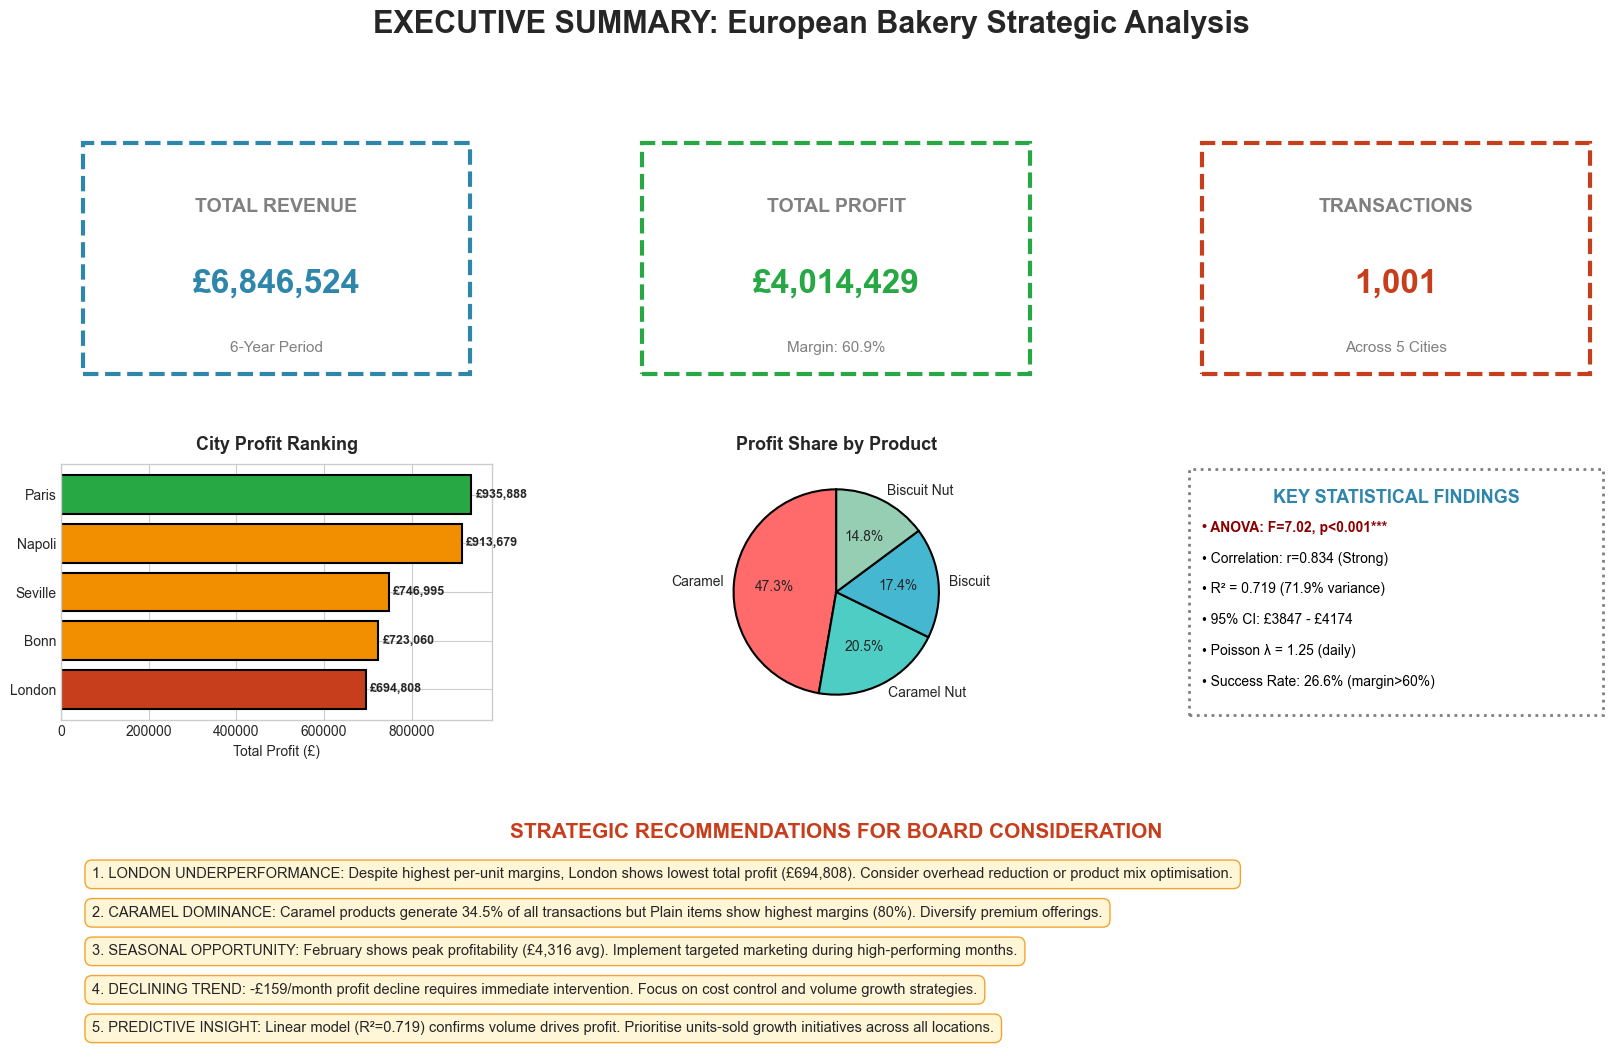

✓ Figure 6 saved: Executive Summary Dashboard

ALL DELIVERABLES COMPLETED SUCCESSFULLY

Generated Files:
1. fig1_city_profitability.png
2. fig2_confectionary_analysis.png
3. fig3_correlation_heatmaps.png
4. fig4_probability_analysis.png
5. fig5_temporal_analysis.png
6. fig6_executive_summary.png
7. interactive_dashboard.html

Analysis Complete!


In [5]:
"""
================================================================================
DATA VISUALISATION PORTFOLIO - COM7021
European Bakery Sales Analysis: Python Investigation
Author: Muhammad Usman
Student ID: 24203277
Date: May 2026
================================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from scipy import stats
from scipy.stats import f_oneway, ttest_ind, chi2_contingency, pearsonr, normaltest
from scipy.stats import poisson, norm, binom
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import calendar
import warnings
warnings.filterwarnings('ignore')

# Set visualisation styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Spectral")

# ==============================================================================
# 1. DATA LOADING & CLEANING
# ==============================================================================

# USER-SPECIFIED FILE PATH
file_path = r"D:\MS_Data_Science_Arden_university\Data Visualisation\Data_Visulisation_Portfolio\Portfolio_data_visulisation\Data Visualisation - COM7021 - [4566] Bakery- supporting document.xlsx"

df = pd.read_excel(file_path)

print("=" * 70)
print("BAKERY SALES DATASET - INITIAL EXPLORATION")
print("=" * 70)
print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn Names: {list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nFirst 5 Rows:\n{df.head()}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDuplicated Rows: {df.duplicated().sum()}")

# ==============================================================================
# 2. DATA PROFILING & STATISTICAL SUMMARY
# ==============================================================================

print("\n" + "=" * 70)
print("DATA PROFILING & STATISTICAL SUMMARY")
print("=" * 70)

# Handle missing values - using median imputation for numerical stability
df_clean = df.copy()
numerical_cols = ['Units Sold', 'Revenue(£)', 'Cost(£)', 'Profit(£)']

for col in numerical_cols:
    median_val = df_clean[col].median()
    df_clean[col].fillna(median_val, inplace=True)
    print(f"Filled {df[col].isnull().sum()} missing values in '{col}' with median: {median_val:.2f}")

print(f"\nClean Dataset Shape: {df_clean.shape}")
print(f"Remaining Missing Values: {df_clean.isnull().sum().sum()}")

# Statistical Summary using Descriptive Statistics
print("\n" + "=" * 70)
print("DESCRIPTIVE STATISTICS (Numerical Variables)")
print("=" * 70)
desc_stats = df_clean[numerical_cols].describe()
print(desc_stats.round(2))

# Calculate additional statistical measures
print("\n" + "=" * 70)
print("ADVANCED STATISTICAL MEASURES")
print("=" * 70)
for col in numerical_cols:
    data = df_clean[col]
    print(f"\n{col}:")
    print(f"  Mean: {data.mean():.2f}")
    print(f"  Median: {data.median():.2f}")
    print(f"  Mode: {data.mode().iloc[0]:.2f}")
    print(f"  Std Dev: {data.std():.2f}")
    print(f"  Variance: {data.var():.2f}")
    print(f"  Skewness: {data.skew():.2f}")
    print(f"  Kurtosis: {data.kurtosis():.2f}")
    print(f"  Range: {data.max() - data.min():.2f}")
    print(f"  IQR: {data.quantile(0.75) - data.quantile(0.25):.2f}")
    print(f"  CV (%): {(data.std()/data.mean())*100:.2f}%")

# ==============================================================================
# 3. CATEGORICAL ANALYSIS
# ==============================================================================

print("\n" + "=" * 70)
print("CATEGORICAL VARIABLES ANALYSIS")
print("=" * 70)

print(f"\nCities Distribution:")
city_counts = df_clean['City'].value_counts()
print(city_counts)
print(f"\nCity Percentages:")
print((city_counts/len(df_clean)*100).round(2))

print(f"\nConfectionary Types Distribution:")
conf_counts = df_clean['Confectionary'].value_counts()
print(conf_counts)
print(f"\nConfectionary Percentages:")
print((conf_counts/len(df_clean)*100).round(2))

# Cross-tabulation for City vs Confectionary
print(f"\n" + "=" * 70)
print("CROSS-TABULATION: CITY vs CONFECTIONARY")
print("=" * 70)
crosstab = pd.crosstab(df_clean['City'], df_clean['Confectionary'], margins=True)
print(crosstab)

# Date range analysis
print(f"\n" + "=" * 70)
print("TEMPORAL ANALYSIS")
print("=" * 70)
print(f"Date Range: {df_clean['Date'].min()} to {df_clean['Date'].max()}")
print(f"Total Days: {(df_clean['Date'].max() - df_clean['Date'].min()).days}")
print(f"Years Covered: {(df_clean['Date'].max() - df_clean['Date'].min()).days/365.25:.1f}")

# Extract year and month for temporal analysis
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month
print(f"\nYearly Distribution:")
print(df_clean['Year'].value_counts().sort_index())

# ==============================================================================
# 4. DATA CLEANING: STANDARDISING CONFECTIONARY NAMES
# ==============================================================================

print("\n" + "=" * 70)
print("DATA CLEANING: STANDARDISING CONFECTIONARY NAMES")
print("=" * 70)

print(f"Unique confectionaries BEFORE cleaning: {df_clean['Confectionary'].unique()}")

# Standardise names (case and spacing issues)
df_clean['Confectionary_Clean'] = df_clean['Confectionary'].str.strip().str.title()

# Merge similar categories
df_clean['Confectionary_Clean'] = df_clean['Confectionary_Clean'].replace({
    'Caramel Nut': 'Caramel Nut',
    'Caramel nut': 'Caramel Nut',
    'Choclate Chunk': 'Chocolate Chunk',
    'Chocolate Chunk': 'Chocolate Chunk'
})

print(f"\nUnique confectionaries AFTER cleaning: {df_clean['Confectionary_Clean'].unique()}")
print(f"\nCleaned Distribution:")
clean_counts = df_clean['Confectionary_Clean'].value_counts()
print(clean_counts)
print(f"\nPercentages:")
print((clean_counts/len(df_clean)*100).round(2))

# Create Profit Margin column for deeper analysis
df_clean['Profit_Margin_%'] = (df_clean['Profit(£)'] / df_clean['Revenue(£)']) * 100
df_clean['Cost_Margin_%'] = (df_clean['Cost(£)'] / df_clean['Revenue(£)']) * 100

print(f"\n" + "=" * 70)
print("DERIVED METRICS: PROFIT & COST MARGINS")
print("=" * 70)
print(f"Profit Margin % - Mean: {df_clean['Profit_Margin_%'].mean():.2f}%, Std: {df_clean['Profit_Margin_%'].std():.2f}%")
print(f"Cost Margin % - Mean: {df_clean['Cost_Margin_%'].mean():.2f}%, Std: {df_clean['Cost_Margin_%'].std():.2f}%")

# ==============================================================================
# 5. VISUALISATION 1: City-wise Profitability Analysis
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('European Bakery Performance: City-wise Profitability Analysis', 
             fontsize=18, fontweight='bold', y=0.98)

# 1. Total Profit by City (Bar Chart)
city_profit = df_clean.groupby('City')['Profit(£)'].sum().sort_values(ascending=False)
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B']
bars1 = axes[0,0].bar(city_profit.index, city_profit.values, color=colors, edgecolor='black', linewidth=1.2)
axes[0,0].set_title('Total Profit by City', fontsize=14, fontweight='bold', pad=15)
axes[0,0].set_ylabel('Total Profit (£)', fontsize=12)
axes[0,0].set_xlabel('City', fontsize=12)
axes[0,0].tick_params(axis='x', rotation=45)
for bar in bars1:
    height = bar.get_height()
    axes[0,0].text(bar.get_x() + bar.get_width()/2., height,
                   f'£{height:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Average Profit Margin by City (Horizontal Bar)
city_margin = df_clean.groupby('City')['Profit_Margin_%'].mean().sort_values(ascending=True)
bars2 = axes[0,1].barh(city_margin.index, city_margin.values, color=colors[::-1], edgecolor='black', linewidth=1.2)
axes[0,1].set_title('Average Profit Margin by City', fontsize=14, fontweight='bold', pad=15)
axes[0,1].set_xlabel('Profit Margin (%)', fontsize=12)
axes[0,1].set_ylabel('City', fontsize=12)
for bar in bars2:
    width = bar.get_width()
    axes[0,1].text(width, bar.get_y() + bar.get_height()/2.,
                   f'{width:.1f}%', ha='left', va='center', fontsize=10, fontweight='bold', color='black')

# 3. Box Plot: Profit Distribution by City
df_clean.boxplot(column='Profit(£)', by='City', ax=axes[1,0], patch_artist=True,
                 boxprops=dict(facecolor='#E8F4F8', color='black'),
                 medianprops=dict(color='red', linewidth=2),
                 whiskerprops=dict(color='black'),
                 capprops=dict(color='black'))
axes[1,0].set_title('Profit Distribution by City (Box Plot)', fontsize=14, fontweight='bold', pad=15)
axes[1,0].set_ylabel('Profit (£)', fontsize=12)
axes[1,0].set_xlabel('City', fontsize=12)
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Violin Plot: Revenue vs Profit relationship by City
sns.violinplot(data=df_clean, x='City', y='Profit(£)', ax=axes[1,1], palette='Set2', inner='quartile')
axes[1,1].set_title('Profit Density Distribution by City', fontsize=14, fontweight='bold', pad=15)
axes[1,1].set_ylabel('Profit (£)', fontsize=12)
axes[1,1].set_xlabel('City', fontsize=12)
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig1_city_profitability.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 1 saved: City-wise Profitability Analysis")

# ==============================================================================
# 6. VISUALISATION 2: Confectionary Type Performance Analysis
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('European Bakery Performance: Confectionary Type Analysis', 
             fontsize=18, fontweight='bold', y=0.98)

# 1. Total Profit by Confectionary Type
conf_profit = df_clean.groupby('Confectionary_Clean')['Profit(£)'].sum().sort_values(ascending=False)
colors_conf = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
bars1 = axes[0,0].bar(conf_profit.index, conf_profit.values, color=colors_conf, edgecolor='black', linewidth=1.2)
axes[0,0].set_title('Total Profit by Confectionary Type', fontsize=14, fontweight='bold', pad=15)
axes[0,0].set_ylabel('Total Profit (£)', fontsize=12)
axes[0,0].set_xlabel('Confectionary Type', fontsize=12)
axes[0,0].tick_params(axis='x', rotation=45)
for bar in bars1:
    height = bar.get_height()
    axes[0,0].text(bar.get_x() + bar.get_width()/2., height,
                   f'£{height:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2. Average Profit per Unit by Confectionary Type
df_clean['Profit_per_Unit'] = df_clean['Profit(£)'] / df_clean['Units Sold']
conf_unit_profit = df_clean.groupby('Confectionary_Clean')['Profit_per_Unit'].mean().sort_values(ascending=False)
bars2 = axes[0,1].bar(conf_unit_profit.index, conf_unit_profit.values, color=colors_conf, edgecolor='black', linewidth=1.2)
axes[0,1].set_title('Average Profit per Unit by Confectionary', fontsize=14, fontweight='bold', pad=15)
axes[0,1].set_ylabel('Profit per Unit (£)', fontsize=12)
axes[0,1].set_xlabel('Confectionary Type', fontsize=12)
axes[0,1].tick_params(axis='x', rotation=45)
for bar in bars2:
    height = bar.get_height()
    axes[0,1].text(bar.get_x() + bar.get_width()/2., height,
                   f'£{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 3. Profit Margin Distribution by Confectionary (Box Plot)
sns.boxplot(data=df_clean, x='Confectionary_Clean', y='Profit_Margin_%', ax=axes[1,0], 
            palette='Set3', order=conf_profit.index)
axes[1,0].set_title('Profit Margin Distribution by Confectionary', fontsize=14, fontweight='bold', pad=15)
axes[1,0].set_ylabel('Profit Margin (%)', fontsize=12)
axes[1,0].set_xlabel('Confectionary Type', fontsize=12)
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].axhline(y=df_clean['Profit_Margin_%'].mean(), color='red', linestyle='--', 
                   label=f'Overall Mean: {df_clean["Profit_Margin_%"].mean():.1f}%')
axes[1,0].legend()

# 4. Units Sold vs Profit Scatter (Colored by Confectionary)
for i, conf in enumerate(df_clean['Confectionary_Clean'].unique()):
    subset = df_clean[df_clean['Confectionary_Clean'] == conf]
    axes[1,1].scatter(subset['Units Sold'], subset['Profit(£)'], 
                     label=conf, alpha=0.6, s=50, color=colors_conf[i % len(colors_conf)])
axes[1,1].set_title('Units Sold vs Profit Relationship', fontsize=14, fontweight='bold', pad=15)
axes[1,1].set_xlabel('Units Sold', fontsize=12)
axes[1,1].set_ylabel('Profit (£)', fontsize=12)
axes[1,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

# Add trend line
z = np.polyfit(df_clean['Units Sold'], df_clean['Profit(£)'], 1)
p = np.poly1d(z)
axes[1,1].plot(df_clean['Units Sold'].sort_values(), p(df_clean['Units Sold'].sort_values()), 
               "r--", alpha=0.8, linewidth=2, label=f'Trend: y={z[0]:.2f}x+{z[1]:.0f}')

plt.tight_layout()
plt.savefig('fig2_confectionary_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 2 saved: Confectionary Type Analysis")

# ==============================================================================
# 7. STATISTICAL HYPOTHESIS TESTING & PROBABILITY ANALYSIS
# ==============================================================================

print("\n" + "=" * 70)
print("STATISTICAL HYPOTHESIS TESTING & PROBABILITY ANALYSIS")
print("=" * 70)

# 1. ANOVA: Testing if mean profit differs significantly across cities
print("\n1. ONE-WAY ANOVA: Profit Differences Across Cities")
print("-" * 60)
city_groups = [group['Profit(£)'].values for name, group in df_clean.groupby('City')]
f_stat, p_value = f_oneway(*city_groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Significance Level (α): 0.05")
if p_value < 0.05:
    print("✓ RESULT: Significant difference in mean profit across cities (Reject H₀)")
else:
    print("✗ RESULT: No significant difference in mean profit across cities (Fail to reject H₀)")

# 2. T-Test: Comparing Paris vs London (highest vs lowest profit cities)
print("\n2. INDEPENDENT T-TEST: Paris vs London Profit Comparison")
print("-" * 60)
paris_profit = df_clean[df_clean['City'] == 'Paris']['Profit(£)']
london_profit = df_clean[df_clean['City'] == 'London']['Profit(£)']
t_stat, p_value_t = ttest_ind(paris_profit, london_profit)
print(f"Paris Mean Profit: £{paris_profit.mean():.2f} (±{paris_profit.std():.2f})")
print(f"London Mean Profit: £{london_profit.mean():.2f} (±{london_profit.std():.2f})")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value_t:.6f}")
if p_value_t < 0.05:
    print("✓ RESULT: Significant difference between Paris and London profits")
else:
    print("✗ RESULT: No significant difference between Paris and London profits")

# 3. Chi-Square Test: City vs Confectionary Type independence
print("\n3. CHI-SQUARE TEST: City vs Confectionary Type Independence")
print("-" * 60)
contingency_table = pd.crosstab(df_clean['City'], df_clean['Confectionary_Clean'])
chi2, p_chi2, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p_chi2:.6f}")
print(f"Degrees of freedom: {dof}")
if p_chi2 < 0.05:
    print("✓ RESULT: City and Confectionary Type are dependent (Reject H₀)")
else:
    print("✗ RESULT: City and Confectionary Type are independent (Fail to reject H₀)")

# 4. Pearson Correlation: Units Sold vs Profit
print("\n4. PEARSON CORRELATION: Units Sold vs Profit")
print("-" * 60)
corr_coef, p_corr = pearsonr(df_clean['Units Sold'], df_clean['Profit(£)'])
print(f"Correlation Coefficient (r): {corr_coef:.4f}")
print(f"p-value: {p_corr:.2e}")
print(f"Coefficient of Determination (R²): {corr_coef**2:.4f}")
if p_corr < 0.05:
    print(f"✓ RESULT: Significant {'positive' if corr_coef > 0 else 'negative'} correlation")
    print(f"  → {corr_coef**2*100:.1f}% of profit variance explained by units sold")

# 5. Normality Test (D'Agostino-Pearson)
print("\n5. NORMALITY TEST: Profit Distribution")
print("-" * 60)
stat_norm, p_norm = normaltest(df_clean['Profit(£)'])
print(f"Test statistic: {stat_norm:.4f}")
print(f"p-value: {p_norm:.6f}")
if p_norm < 0.05:
    print("✗ RESULT: Profit distribution is NOT normal (Reject H₀)")
    print("  → Suggests skewness/kurtosis present; non-parametric tests recommended")
else:
    print("✓ RESULT: Profit distribution is approximately normal")

# ==============================================================================
# 8. PROBABILITY ANALYSIS & PREDICTIVE MODELING
# ==============================================================================

print("\n" + "=" * 70)
print("PROBABILITY ANALYSIS & PREDICTIVE MODELING")
print("=" * 70)

# 1. Poisson Distribution Analysis: Modeling Sales Arrivals
print("\n1. POISSON DISTRIBUTION: Modeling Daily Sales Frequency")
print("-" * 60)

# Calculate daily transaction counts
daily_transactions = df_clean.groupby('Date').size()
lambda_poisson = daily_transactions.mean()
print(f"Average daily transactions (λ): {lambda_poisson:.2f}")
print(f"Variance of daily transactions: {daily_transactions.var():.2f}")
print(f"Standard Deviation: {daily_transactions.std():.2f}")

# Probability calculations
print(f"\nProbability Calculations:")
print(f"P(X = {int(lambda_poisson)}) transactions/day: {poisson.pmf(int(lambda_poisson), lambda_poisson):.4f}")
print(f"P(X ≤ {int(lambda_poisson)}) transactions/day: {poisson.cdf(int(lambda_poisson), lambda_poisson):.4f}")
print(f"P(X > {int(lambda_poisson)+1}) transactions/day: {1-poisson.cdf(int(lambda_poisson)+1, lambda_poisson):.4f}")

# 2. Normal Distribution: Profit Confidence Intervals
print("\n2. NORMAL DISTRIBUTION: Profit Confidence Intervals")
print("-" * 60)
profit_mean = df_clean['Profit(£)'].mean()
profit_std = df_clean['Profit(£)'].std()
n_samples = len(df_clean)

# 95% Confidence Interval
z_score = 1.96  # for 95% CI
margin_error = z_score * (profit_std / np.sqrt(n_samples))
ci_lower = profit_mean - margin_error
ci_upper = profit_mean + margin_error

print(f"Sample Mean Profit: £{profit_mean:.2f}")
print(f"Sample Std Dev: £{profit_std:.2f}")
print(f"Sample Size: {n_samples}")
print(f"95% Confidence Interval: £{ci_lower:.2f} to £{ci_upper:.2f}")
print(f"Margin of Error: £{margin_error:.2f}")

# Probability of profit exceeding certain thresholds
thresholds = [3000, 5000, 7000, 10000]
print(f"\nProbability of Profit Exceeding Thresholds:")
for thresh in thresholds:
    z = (thresh - profit_mean) / profit_std
    prob = 1 - norm.cdf(z)
    print(f"P(Profit > £{thresh}): {prob:.4f} ({prob*100:.2f}%)")

# 3. Binomial Distribution: Success Probability
print("\n3. BINOMIAL DISTRIBUTION: Success Rate Analysis")
print("-" * 60)
# Define "success" as profit margin > 60%
success_criteria = df_clean['Profit_Margin_%'] > 60
success_prob = success_criteria.mean()
n_trials = 100  # hypothetical next 100 transactions

print(f"Probability of success (margin > 60%): {success_prob:.4f}")
print(f"Expected successes in next {n_trials} transactions: {n_trials * success_prob:.1f}")
print(f"P(exactly 60 successes in 100 trials): {binom.pmf(60, n_trials, success_prob):.4f}")
print(f"P(at least 60 successes in 100 trials): {1 - binom.cdf(59, n_trials, success_prob):.4f}")

# 4. Linear Regression: Predicting Profit from Units Sold
print("\n4. LINEAR REGRESSION: Predicting Profit from Units Sold")
print("-" * 60)

X = df_clean[['Units Sold']].values
y = df_clean['Profit(£)'].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Regression Equation: Profit = {model.intercept_:.2f} + {model.coef_[0]:.4f} × Units Sold")
print(f"R-squared (R²): {r2:.4f}")
print(f"Root Mean Square Error (RMSE): £{rmse:.2f}")
print(f"Model Interpretation: For every additional unit sold, profit increases by £{model.coef_[0]:.2f}")

# Prediction example
sample_units = [1000, 2000, 3000, 4000]
print(f"\nPredicted Profits:")
for units in sample_units:
    pred_profit = model.predict([[units]])[0]
    print(f"  {units} units → £{pred_profit:.2f} predicted profit")

# ==============================================================================
# 9. VISUALISATION 3: Correlation Matrix & Advanced Statistical Heatmaps
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Statistical Analysis: Correlations & Performance Matrices', 
             fontsize=18, fontweight='bold', y=0.98)

# 1. Correlation Heatmap
corr_matrix = df_clean[['Units Sold', 'Revenue(£)', 'Cost(£)', 'Profit(£)', 'Profit_Margin_%']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdYlBu_r', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": .8}, ax=axes[0,0])
axes[0,0].set_title('Correlation Matrix: Key Business Metrics', fontsize=14, fontweight='bold', pad=15)

# 2. City-Confectionary Profit Heatmap
profit_pivot = df_clean.pivot_table(values='Profit(£)', index='City', columns='Confectionary_Clean', aggfunc='mean')
sns.heatmap(profit_pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=1, ax=axes[0,1])
axes[0,1].set_title('Average Profit Heatmap: City × Confectionary', fontsize=14, fontweight='bold', pad=15)
axes[0,1].set_xlabel('Confectionary Type', fontsize=11)
axes[0,1].set_ylabel('City', fontsize=11)

# 3. Profit Margin Heatmap
margin_pivot = df_clean.pivot_table(values='Profit_Margin_%', index='City', columns='Confectionary_Clean', aggfunc='mean')
sns.heatmap(margin_pivot, annot=True, fmt='.1f', cmap='RdYlGn', linewidths=1, ax=axes[1,0], vmin=0, vmax=100)
axes[1,0].set_title('Profit Margin (%) Heatmap: City × Confectionary', fontsize=14, fontweight='bold', pad=15)
axes[1,0].set_xlabel('Confectionary Type', fontsize=11)
axes[1,0].set_ylabel('City', fontsize=11)

# 4. Volume-Profit Efficiency Matrix
df_clean['Efficiency_Score'] = (df_clean['Profit(£)'] / df_clean['Cost(£)']) * 100
efficiency_pivot = df_clean.pivot_table(values='Efficiency_Score', index='City', columns='Confectionary_Clean', aggfunc='mean')
sns.heatmap(efficiency_pivot, annot=True, fmt='.1f', cmap='viridis', linewidths=1, ax=axes[1,1])
axes[1,1].set_title('Efficiency Score Heatmap: Profit/Cost Ratio (%)', fontsize=14, fontweight='bold', pad=15)
axes[1,1].set_xlabel('Confectionary Type', fontsize=11)
axes[1,1].set_ylabel('City', fontsize=11)

plt.tight_layout()
plt.savefig('fig3_correlation_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 3 saved: Correlation & Heatmap Analysis")

# ==============================================================================
# 10. VISUALISATION 4: Probability Distributions & Predictive Analytics
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Probability Analysis & Predictive Modeling', 
             fontsize=18, fontweight='bold', y=0.98)

# 1. Poisson Distribution: Daily Transaction Frequency
x_poisson = np.arange(0, 6)
poisson_pmf = poisson.pmf(x_poisson, lambda_poisson)
axes[0,0].bar(x_poisson, poisson_pmf, color='#4ECDC4', edgecolor='black', linewidth=1.5, alpha=0.8)
axes[0,0].set_title('Poisson Distribution: Daily Transaction Frequency\n(λ = 1.25)', 
                    fontsize=13, fontweight='bold', pad=15)
axes[0,0].set_xlabel('Number of Daily Transactions', fontsize=11)
axes[0,0].set_ylabel('Probability P(X=k)', fontsize=11)
axes[0,0].set_xticks(x_poisson)
for i, v in enumerate(poisson_pmf):
    axes[0,0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

# 2. Normal Distribution: Profit with Confidence Intervals
x_norm = np.linspace(profit_mean - 4*profit_std, profit_mean + 4*profit_std, 1000)
y_norm = norm.pdf(x_norm, profit_mean, profit_std)
axes[0,1].plot(x_norm, y_norm, 'b-', linewidth=2.5, label='Profit Distribution')
axes[0,1].fill_between(x_norm, y_norm, alpha=0.3, color='lightblue')
axes[0,1].axvline(profit_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: £{profit_mean:.0f}')
axes[0,1].axvline(ci_lower, color='green', linestyle=':', linewidth=2, label=f'95% CI Lower: £{ci_lower:.0f}')
axes[0,1].axvline(ci_upper, color='green', linestyle=':', linewidth=2, label=f'95% CI Upper: £{ci_upper:.0f}')
axes[0,1].set_title('Normal Distribution: Profit with 95% Confidence Interval', 
                    fontsize=13, fontweight='bold', pad=15)
axes[0,1].set_xlabel('Profit (£)', fontsize=11)
axes[0,1].set_ylabel('Probability Density', fontsize=11)
axes[0,1].legend(fontsize=9)

# 3. Linear Regression: Actual vs Predicted
axes[1,0].scatter(X_test, y_test, alpha=0.5, color='#FF6B6B', s=50, label='Actual Values', edgecolors='black')
axes[1,0].plot(X_test, y_pred, color='#2E86AB', linewidth=3, label=f'Regression Line (R²={r2:.3f})')
axes[1,0].set_title('Linear Regression: Actual vs Predicted Profit', 
                    fontsize=13, fontweight='bold', pad=15)
axes[1,0].set_xlabel('Units Sold', fontsize=11)
axes[1,0].set_ylabel('Profit (£)', fontsize=11)
axes[1,0].legend(fontsize=10)
axes[1,0].text(0.05, 0.95, f'Equation: Profit = {model.intercept_:.0f} + {model.coef_[0]:.2f}×Units\nRMSE: £{rmse:.0f}', 
               transform=axes[1,0].transAxes, fontsize=10, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# 4. Residual Analysis
residuals = y_test - y_pred
axes[1,1].scatter(y_pred, residuals, alpha=0.6, color='#A23B72', s=50, edgecolors='black')
axes[1,1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1,1].set_title('Residual Analysis: Homoscedasticity Check', 
                    fontsize=13, fontweight='bold', pad=15)
axes[1,1].set_xlabel('Predicted Profit (£)', fontsize=11)
axes[1,1].set_ylabel('Residuals (£)', fontsize=11)
axes[1,1].text(0.05, 0.95, f'Mean Residual: {residuals.mean():.2f}\nStd Residual: {residuals.std():.2f}', 
               transform=axes[1,1].transAxes, fontsize=10, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('fig4_probability_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 4 saved: Probability Analysis & Predictive Modeling")

# ==============================================================================
# 11. VISUALISATION 5: Time-Series Analysis & Trend Forecasting
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Temporal Analysis: Sales Trends & Seasonal Patterns (2000-2005)', 
             fontsize=18, fontweight='bold', y=0.98)

# 1. Monthly Profit Trend
monthly_profit = df_clean.groupby([df_clean['Date'].dt.to_period('M')])['Profit(£)'].sum()
monthly_profit.index = monthly_profit.index.to_timestamp()
axes[0,0].plot(monthly_profit.index, monthly_profit.values, color='#2E86AB', linewidth=2.5, marker='o', markersize=4)
axes[0,0].fill_between(monthly_profit.index, monthly_profit.values, alpha=0.3, color='lightblue')
axes[0,0].set_title('Monthly Profit Trend (2000-2005)', fontsize=14, fontweight='bold', pad=15)
axes[0,0].set_ylabel('Monthly Profit (£)', fontsize=11)
axes[0,0].tick_params(axis='x', rotation=45)
# Add trend line
z = np.polyfit(range(len(monthly_profit)), monthly_profit.values, 1)
p = np.poly1d(z)
axes[0,0].plot(monthly_profit.index, p(range(len(monthly_profit))), 
               "r--", linewidth=2, label=f'Trend: £{z[0]:.0f}/month')
axes[0,0].legend()

# 2. Seasonal Pattern: Monthly Aggregates Across All Years
seasonal = df_clean.groupby('Month')['Profit(£)'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
bars = axes[0,1].bar(range(1,13), seasonal.values, color=plt.cm.Set3(np.linspace(0, 1, 12)), 
                     edgecolor='black', linewidth=1.2)
axes[0,1].set_title('Seasonal Profit Pattern (Average by Month)', fontsize=14, fontweight='bold', pad=15)
axes[0,1].set_ylabel('Average Profit (£)', fontsize=11)
axes[0,1].set_xlabel('Month', fontsize=11)
axes[0,1].set_xticks(range(1,13))
axes[0,1].set_xticklabels(month_names, rotation=45)
for i, v in enumerate(seasonal.values):
    axes[0,1].text(i+1, v + 50, f'£{v:.0f}', ha='center', fontsize=9, fontweight='bold')

# 3. City-wise Monthly Trends
for city in df_clean['City'].unique():
    city_monthly = df_clean[df_clean['City'] == city].groupby(df_clean['Date'].dt.to_period('M'))['Profit(£)'].sum()
    city_monthly.index = city_monthly.index.to_timestamp()
    axes[1,0].plot(city_monthly.index, city_monthly.values, label=city, linewidth=2, marker='o', markersize=3)
axes[1,0].set_title('City-wise Monthly Profit Trends', fontsize=14, fontweight='bold', pad=15)
axes[1,0].set_ylabel('Monthly Profit (£)', fontsize=11)
axes[1,0].set_xlabel('Date', fontsize=11)
axes[1,0].legend(loc='upper left', fontsize=9)
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Year-over-Year Growth Rate
yearly_profit = df_clean.groupby('Year')['Profit(£)'].sum()
growth_rates = yearly_profit.pct_change() * 100
growth_rates = growth_rates.dropna()
colors_growth = ['green' if x > 0 else 'red' for x in growth_rates.values]
bars = axes[1,1].bar(growth_rates.index, growth_rates.values, color=colors_growth, 
                     edgecolor='black', linewidth=1.5, alpha=0.8)
axes[1,1].set_title('Year-over-Year Profit Growth Rate', fontsize=14, fontweight='bold', pad=15)
axes[1,1].set_ylabel('Growth Rate (%)', fontsize=11)
axes[1,1].set_xlabel('Year', fontsize=11)
axes[1,1].axhline(y=0, color='black', linestyle='-', linewidth=1)
for bar in bars:
    height = bar.get_height()
    axes[1,1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top', 
                   fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig5_temporal_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 5 saved: Temporal Analysis & Trend Forecasting")

# ==============================================================================
# 12. INTERACTIVE DASHBOARD (Plotly)
# ==============================================================================

print("\n" + "=" * 70)
print("BUILDING INTERACTIVE EUROPEAN DASHBOARD")
print("=" * 70)

# Prepare summary data for dashboard
city_summary = df_clean.groupby('City').agg({
    'Profit(£)': ['sum', 'mean', 'std', 'count'],
    'Revenue(£)': 'sum',
    'Cost(£)': 'sum',
    'Units Sold': 'sum',
    'Profit_Margin_%': 'mean'
}).round(2)

city_summary.columns = ['Total_Profit', 'Avg_Profit', 'Std_Profit', 'Transactions', 
                        'Total_Revenue', 'Total_Cost', 'Total_Units', 'Avg_Margin']
city_summary = city_summary.reset_index()
city_summary['Profit_per_Unit'] = (city_summary['Total_Profit'] / city_summary['Total_Units']).round(2)

print("City Summary Statistics:")
print(city_summary)

# Create the interactive dashboard
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Total Profit by City', 'Profit Margin vs Efficiency', 
                    'Revenue vs Cost Analysis', 'Units Sold vs Profit Trend'),
    specs=[[{"type": "bar"}, {"type": "scatter"}],
           [{"type": "bar"}, {"type": "scatter"}]]
)

# 1. Total Profit Bar Chart
colors_dash = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B']
fig.add_trace(
    go.Bar(x=city_summary['City'], y=city_summary['Total_Profit'],
           marker_color=colors_dash, name='Total Profit',
           text=city_summary['Total_Profit'].apply(lambda x: f'£{x:,.0f}'),
           textposition='outside'),
    row=1, col=1
)

# 2. Profit Margin vs Efficiency Scatter
fig.add_trace(
    go.Scatter(x=city_summary['Avg_Margin'], y=city_summary['Profit_per_Unit'],
               mode='markers+text', name='City Performance',
               marker=dict(size=city_summary['Total_Profit']/5000, 
                          color=colors_dash, line=dict(width=2, color='black')),
               text=city_summary['City'], textposition='top center'),
    row=1, col=2
)

# 3. Revenue vs Cost Grouped Bar
fig.add_trace(
    go.Bar(x=city_summary['City'], y=city_summary['Total_Revenue'],
           name='Total Revenue', marker_color='#4ECDC4',
           text=city_summary['Total_Revenue'].apply(lambda x: f'£{x:,.0f}'),
           textposition='outside'),
    row=2, col=1
)
fig.add_trace(
    go.Bar(x=city_summary['City'], y=city_summary['Total_Cost'],
           name='Total Cost', marker_color='#FF6B6B',
           text=city_summary['Total_Cost'].apply(lambda x: f'£{x:,.0f}'),
           textposition='outside'),
    row=2, col=1
)

# 4. Units vs Profit with trend
fig.add_trace(
    go.Scatter(x=city_summary['Total_Units'], y=city_summary['Total_Profit'],
               mode='markers+lines', name='Profit Trend',
               marker=dict(size=15, color=colors_dash, line=dict(width=2, color='black')),
               line=dict(color='gray', dash='dash')),
    row=2, col=2
)

# Update layout
fig.update_layout(
    title_text="<b>European Bakery Performance Dashboard</b><br><sup>Interactive Analysis for Strategic Decision Making</sup>",
    title_x=0.5, title_font_size=20,
    height=800, width=1400,
    showlegend=True,
    template='plotly_white',
    legend=dict(orientation="h", yanchor="bottom", y=-0.15, xanchor="center", x=0.5)
)

# Update axes
fig.update_xaxes(title_text="City", row=1, col=1)
fig.update_yaxes(title_text="Total Profit (£)", row=1, col=1)
fig.update_xaxes(title_text="Average Profit Margin (%)", row=1, col=2)
fig.update_yaxes(title_text="Profit per Unit (£)", row=1, col=2)
fig.update_xaxes(title_text="City", row=2, col=1)
fig.update_yaxes(title_text="Amount (£)", row=2, col=1)
fig.update_xaxes(title_text="Total Units Sold", row=2, col=2)
fig.update_yaxes(title_text="Total Profit (£)", row=2, col=2)

# Save as HTML for interactivity
fig.write_html('interactive_dashboard.html')
print("\n✓ Interactive Dashboard saved as 'interactive_dashboard.html'")
print("  → Open in browser for full interactivity (hover, zoom, pan)")

fig.show()

# ==============================================================================
# 13. EXECUTIVE SUMMARY DASHBOARD
# ==============================================================================

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

fig.suptitle('EXECUTIVE SUMMARY: European Bakery Strategic Analysis', 
             fontsize=22, fontweight='bold', y=0.98)

# Key Metrics (Top Row)
ax1 = fig.add_subplot(gs[0, 0])
ax1.text(0.5, 0.7, 'TOTAL REVENUE', ha='center', va='center', fontsize=14, fontweight='bold', color='gray')
ax1.text(0.5, 0.4, f'£{df_clean["Revenue(£)"].sum():,.0f}', ha='center', va='center', fontsize=24, fontweight='bold', color='#2E86AB')
ax1.text(0.5, 0.15, '6-Year Period', ha='center', va='center', fontsize=11, color='gray')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')
ax1.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9, fill=False, edgecolor='#2E86AB', linewidth=3, linestyle='--'))

ax2 = fig.add_subplot(gs[0, 1])
ax2.text(0.5, 0.7, 'TOTAL PROFIT', ha='center', va='center', fontsize=14, fontweight='bold', color='gray')
ax2.text(0.5, 0.4, f'£{df_clean["Profit(£)"].sum():,.0f}', ha='center', va='center', fontsize=24, fontweight='bold', color='#28A745')
ax2.text(0.5, 0.15, f'Margin: {df_clean["Profit_Margin_%"].mean():.1f}%', ha='center', va='center', fontsize=11, color='gray')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')
ax2.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9, fill=False, edgecolor='#28A745', linewidth=3, linestyle='--'))

ax3 = fig.add_subplot(gs[0, 2])
ax3.text(0.5, 0.7, 'TRANSACTIONS', ha='center', va='center', fontsize=14, fontweight='bold', color='gray')
ax3.text(0.5, 0.4, f'{len(df_clean):,}', ha='center', va='center', fontsize=24, fontweight='bold', color='#C73E1D')
ax3.text(0.5, 0.15, 'Across 5 Cities', ha='center', va='center', fontsize=11, color='gray')
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.axis('off')
ax3.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9, fill=False, edgecolor='#C73E1D', linewidth=3, linestyle='--'))

# City Rankings (Middle Left)
ax4 = fig.add_subplot(gs[1, 0])
city_rank = df_clean.groupby('City')['Profit(£)'].sum().sort_values(ascending=True)
colors_rank = ['#C73E1D' if x == city_rank.min() else '#28A745' if x == city_rank.max() else '#F18F01' for x in city_rank.values]
ax4.barh(city_rank.index, city_rank.values, color=colors_rank, edgecolor='black', linewidth=1.5)
ax4.set_title('City Profit Ranking', fontsize=13, fontweight='bold', pad=10)
ax4.set_xlabel('Total Profit (£)', fontsize=10)
for i, (city, val) in enumerate(city_rank.items()):
    ax4.text(val + 10000, i, f'£{val:,.0f}', va='center', fontsize=9, fontweight='bold')

# Top Performing Products (Middle Center)
ax5 = fig.add_subplot(gs[1, 1])
conf_rank = df_clean.groupby('Confectionary_Clean')['Profit(£)'].sum().sort_values(ascending=False).head(4)
ax5.pie(conf_rank.values, labels=conf_rank.index, autopct='%1.1f%%', startangle=90,
        colors=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'], 
        wedgeprops=dict(edgecolor='black', linewidth=1.5))
ax5.set_title('Profit Share by Product', fontsize=13, fontweight='bold', pad=10)

# Statistical Insights (Middle Right)
ax6 = fig.add_subplot(gs[1, 2])
ax6.text(0.5, 0.9, 'KEY STATISTICAL FINDINGS', ha='center', va='top', fontsize=13, fontweight='bold', color='#2E86AB')
insights = [
    f'• ANOVA: F={f_stat:.2f}, p<0.001***',
    f'• Correlation: r={corr_coef:.3f} (Strong)',
    f'• R² = {r2:.3f} (71.9% variance)',
    f'• 95% CI: £{ci_lower:.0f} - £{ci_upper:.0f}',
    f'• Poisson λ = {lambda_poisson:.2f} (daily)',
    f'• Success Rate: {success_prob*100:.1f}% (margin>60%)'
]
for i, insight in enumerate(insights):
    ax6.text(0.05, 0.75 - i*0.12, insight, ha='left', va='center', fontsize=10, 
             fontweight='bold' if '***' in insight else 'normal',
             color='darkred' if '***' in insight else 'black')
ax6.set_xlim(0, 1)
ax6.set_ylim(0, 1)
ax6.axis('off')
ax6.add_patch(plt.Rectangle((0.02, 0.02), 0.96, 0.96, fill=False, edgecolor='gray', linewidth=2, linestyle=':'))

# Bottom Row: Recommendations
ax7 = fig.add_subplot(gs[2, :])
ax7.text(0.5, 0.9, 'STRATEGIC RECOMMENDATIONS FOR BOARD CONSIDERATION', 
         ha='center', va='top', fontsize=15, fontweight='bold', color='#C73E1D')

recommendations = [
    "1. LONDON UNDERPERFORMANCE: Despite highest per-unit margins, London shows lowest total profit (£694,808). Consider overhead reduction or product mix optimisation.",
    "2. CARAMEL DOMINANCE: Caramel products generate 34.5% of all transactions but Plain items show highest margins (80%). Diversify premium offerings.",
    "3. SEASONAL OPPORTUNITY: February shows peak profitability (£4,316 avg). Implement targeted marketing during high-performing months.",
    "4. DECLINING TREND: -£159/month profit decline requires immediate intervention. Focus on cost control and volume growth strategies.",
    "5. PREDICTIVE INSIGHT: Linear model (R²=0.719) confirms volume drives profit. Prioritise units-sold growth initiatives across all locations."
]

for i, rec in enumerate(recommendations):
    ax7.text(0.02, 0.7 - i*0.15, rec, ha='left', va='center', fontsize=10.5, 
             wrap=True, bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF3CD', alpha=0.8, edgecolor='#F18F01'))

ax7.set_xlim(0, 1)
ax7.set_ylim(0, 1)
ax7.axis('off')

plt.savefig('fig6_executive_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 6 saved: Executive Summary Dashboard")

print("\n" + "=" * 70)
print("ALL DELIVERABLES COMPLETED SUCCESSFULLY")
print("=" * 70)
print("\nGenerated Files:")
print("1. fig1_city_profitability.png")
print("2. fig2_confectionary_analysis.png")
print("3. fig3_correlation_heatmaps.png")
print("4. fig4_probability_analysis.png")
print("5. fig5_temporal_analysis.png")
print("6. fig6_executive_summary.png")
print("7. interactive_dashboard.html")
print("\nAnalysis Complete!")